In [97]:
import polars as pl
import torch
import torch.nn as nn
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from model import *
from visualization import *
from triplet_loss import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

In [11]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [12]:
train_loader = DataLoader(train_dataset, batch_size=512, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

47758


In [13]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([  0.5014, 180.1141])

In [16]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)

In [17]:
model

ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=15, out_features=2, bias=False)
)

In [ ]:
model.proto_layer.prototype_labels

In [20]:
samples = []
labels = []
num_per_type = 2
for anomaly_type in range(1,6):
    indices = np.where(y_train_anomalies == anomaly_type)[0]
    chosen = np.random.permutation(indices)[:num_per_type]

    # Add to the list
    samples.append(torch.tensor(X_train[chosen], dtype=torch.float32))
    labels.append(torch.tensor(y_train_anomalies[chosen], dtype=torch.long))

X_triplet = torch.cat(samples, dim=0)
y_triplet = torch.cat(labels)


In [ ]:
train_protopnet_triplet(model, train_loader, val_loader, epochs=6, X_triplet=X_triplet, y_triplet=y_triplet, lr=0.0001, class_weights=class_weights, lambda_triplet=0.5, lambda_clst=0.8, lambda_sep=0.08)

tensor([  0.5014, 180.1141])

Epoch 1/6


Epoch 1/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.3481
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.28570022338390255
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.1498
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.34      0.90      0.50      6708

    accuracy                           1.00   2486401
   macro avg       0.67      0.95      0.75   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.7472

Epoch 2/6


Epoch 2/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.4298
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.12925337166634762
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.0523
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.38      0.96      0.55      6708

    accuracy                           1.00   2486401
   macro avg       0.69      0.98      0.77   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.7721

Epoch 3/6


...

Epoch 4/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -1.3734
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.13296626644095266
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.0761
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.69      0.95      0.80      6708

    accuracy                           1.00   2486401
   macro avg       0.85      0.97      0.90   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8993

Epoch 5/6


Epoch 5/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -1.9969
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.12811911911900445
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.0842
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.71      0.94      0.81      6708

    accuracy                           1.00   2486401
   macro avg       0.85      0.97      0.90   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9029

Epoch 6/6


Epoch 6/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

In [98]:
#lambda_triplet_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
lambda_triplet_values = [100.0]


for lambda_triplet in lambda_triplet_values:
    model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)
    print(f"\n Training with lambda_triplet = {lambda_triplet}")
    
    # Format lambda value for filename (e.g., 0.3 → "0_3")
    lambda_str = str(lambda_triplet).replace('.', '_')
    
    # Construct unique filename for this experiment
    filepath = f"model_ppnet_best_triplet_lambda_{lambda_str}.pth"
    print(f"Saving to {filepath}")
    train_protopnet_triplet(model, 
                            train_loader, 
                            val_loader, 
                            epochs=6, 
                            X_triplet=X_triplet, 
                            y_triplet=y_triplet, 
                            lr=0.0001, 
                            class_weights=class_weights, 
                            lambda_triplet=lambda_triplet, 
                            lambda_clst=0.8, 
                            lambda_sep=0.08,
                            filepath=filepath)


 Training with lambda_triplet = 100.0
Saving to model_ppnet_best_triplet_lambda_100_0.pth
100.0

Epoch 1/6


Epoch 1/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.1070
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.26428763873785943
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.1539
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   2479693
           1       0.32      0.91      0.47      6708

    accuracy                           0.99   2486401
   macro avg       0.66      0.95      0.74   2486401
weighted avg       1.00      0.99      1.00   2486401

New best model saved with Macro F1 = 0.7361

Epoch 2/6


Epoch 2/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.3551
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.16156435421327592
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.1118
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.58      0.92      0.71      6708

    accuracy                           1.00   2486401
   macro avg       0.79      0.96      0.86   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8559

Epoch 3/6


...

Phase 1 - Training Loss: -1.4615
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.10316922536545771
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.1029
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.71      0.92      0.80      6708

    accuracy                           1.00   2486401
   macro avg       0.85      0.96      0.90   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9000

Epoch 5/6


Epoch 5/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -2.2328
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.07944291220241088
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.0795
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.72      0.94      0.81      6708

    accuracy                           1.00   2486401
   macro avg       0.86      0.97      0.91   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9062

Epoch 6/6


Epoch 6/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -3.0541
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.07378010970842308
Phase 3 - Last Layer Optimization Completed
Epoch 6: Val Loss = 0.0712
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.72      0.95      0.82      6708

    accuracy                           1.00   2486401
   macro avg       0.86      0.97      0.91   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9087


In [46]:
p = model.proto_layer.prototypes[0]
p.unsqueeze(0).size()

torch.Size([1, 16])

In [85]:
model.load_state_dict(torch.load("model_ppnet_best_triplet_lambda_5_0.pth"))

<All keys matched successfully>

In [108]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, z_train, distances, y_logits = model(X_train_tensor)
    y_probs_train = F.softmax(y_logits, dim=1)
    y_pred_train = torch.argmax(y_probs_train, dim=1)
y_pred_train = y_pred_train.cpu().numpy()
y_probs_train = y_probs_train.cpu().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()
print(z_train.shape)
print(distances)

(24451934,)
(24451934, 16)
tensor([[12.0333,  8.1533, 20.6614,  ..., 12.4473, 12.4215, 10.1202],
        [27.3282, 29.2176, 18.0426,  ..., 48.7672, 47.7363, 47.3321],
        [27.3283, 29.2176, 18.0427,  ..., 48.7673, 47.7364, 47.3322],
        ...,
        [27.3880, 30.3366, 17.9749,  ..., 49.1028, 47.8577, 48.0833],
        [27.3878, 30.3364, 17.9746,  ..., 49.1026, 47.8573, 48.0831],
        [27.3884, 30.3370, 17.9753,  ..., 49.1032, 47.8580, 48.0837]])


In [99]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, distances, y_logits = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)
print(distances)

(2765755,)
(2765755, 16)
tensor([[20.6037, 18.7454, 29.9597,  ...,  1.5604,  2.7324,  3.5775],
        [27.5343, 30.4538, 18.1130,  ..., 49.2432, 48.0009, 48.2162],
        [27.3831, 30.3306, 17.9699,  ..., 49.0981, 47.8532, 48.0780],
        ...,
        [27.4002, 30.3464, 17.9866,  ..., 49.1149, 47.8701, 48.0945],
        [27.4033, 30.3487, 17.9896,  ..., 49.1180, 47.8733, 48.0973],
        [27.4049, 30.3504, 17.9912,  ..., 49.1196, 47.8748, 48.0989]])


In [100]:
print(classification_report(y_test, y_pred_test, digits=4))


              precision    recall  f1-score   support

           0     0.9999    0.9980    0.9990   2759074
           1     0.5386    0.9687    0.6923      6681

    accuracy                         0.9979   2765755
   macro avg     0.7692    0.9834    0.8456   2765755
weighted avg     0.9988    0.9979    0.9982   2765755



In [109]:
print(classification_report(y_train, y_pred_train, digits=4))


              precision    recall  f1-score   support

           0     0.9999    0.9912    0.9955  24384055
           1     0.2334    0.9632    0.3757     67879

    accuracy                         0.9911  24451934
   macro avg     0.6166    0.9772    0.6856  24451934
weighted avg     0.9978    0.9911    0.9938  24451934



In [101]:
print(confusion_matrix(y_test, y_pred_test))


[[2753529    5545]
 [    209    6472]]


In [89]:
print(distances.shape)
print(prototypes.shape)

torch.Size([2765755, 15])
(15, 16)


In [102]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=70000, anomaly_ratio=0.1)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]
print(z_sampled.shape)

[6681]
63000
2759074
63000
(69681, 16)


In [110]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_train, y_train, n_samples=200000, anomaly_ratio=0.1)
y_pred_sampled = y_pred_train[selected_indices]
y_train_anomalies_sampled = y_train_anomalies[selected_indices]
print(z_sampled.shape)

[67879]
180000
24384055
180000
(200000, 16)


In [111]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(200000, 2)

In [112]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(15, 2)

In [113]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]

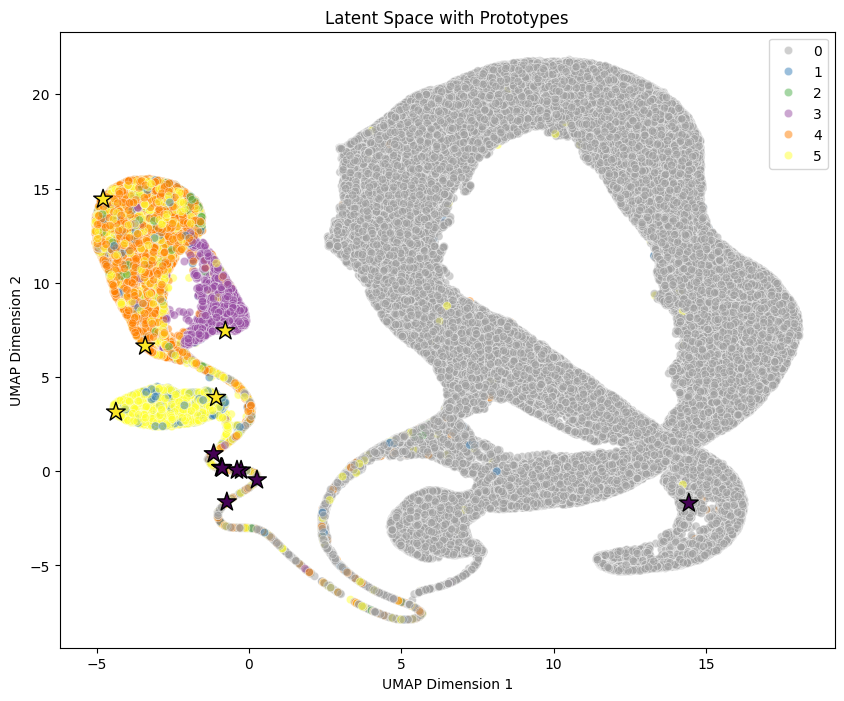

In [115]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

# Plot prototypes as red stars
plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=model.proto_layer.prototype_labels, marker='*', s=200, edgecolors='black')

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes")
plt.legend()
plt.show()

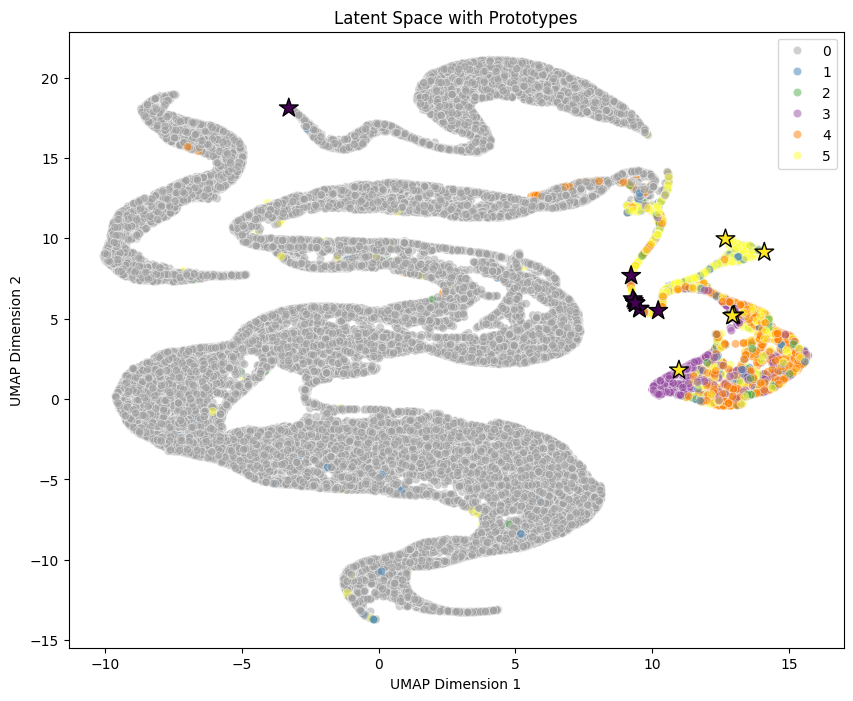

In [76]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_anomalies_sampled, alpha=0.5, palette=custom_palette)

# Plot prototypes as red stars
plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=model.proto_layer.prototype_labels, marker='*', s=200, edgecolors='black')

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes")
plt.legend()
plt.show()

In [19]:
model.proto_layer.prototype_labels

tensor([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

In [20]:
adjusted_rand_score(y_test, y_pred_test)

0.7853823477458157

In [22]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train_tensor)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

for i, dist in enumerate(distances):
    print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")

Prototype 0: Closest training point at index 516, Distance: 0.0000
Prototype 1: Closest training point at index 4603445, Distance: 0.0000
Prototype 2: Closest training point at index 516, Distance: 0.0000
Prototype 3: Closest training point at index 4603445, Distance: 0.0000
Prototype 4: Closest training point at index 715829, Distance: 0.0020
Prototype 5: Closest training point at index 4603445, Distance: 0.0000
Prototype 6: Closest training point at index 516, Distance: 0.0000
Prototype 7: Closest training point at index 4603445, Distance: 0.0000
Prototype 8: Closest training point at index 580970, Distance: 0.0000
Prototype 9: Closest training point at index 4603445, Distance: 0.0000
Prototype 10: Closest training point at index 5017, Distance: 0.0000
Prototype 11: Closest training point at index 4603445, Distance: 0.0000
Prototype 12: Closest training point at index 516, Distance: 0.0000
Prototype 13: Closest training point at index 4603445, Distance: 0.0000
Prototype 14: Closest t